## 1. Importing Libraries and setting up CUDA



In [1]:
import os
import shutil
from IPython.display import Image, clear_output

import numpy as np
import torch
import json

In [2]:
device = 'cuda' if torch.cuda.is_available() else "cpu"
device

'cuda'

## 2. Preparing Data for Training


### 2.1 Verifications of Dataset Structure


In [3]:
for dirpath, dirnames, filenames in os.walk("/kaggle/input/"):
    for dirname in dirnames:
        full_path = os.path.join(dirpath, dirname)
        print(full_path)

/kaggle/input/datasets
/kaggle/input/datasets/awsaf49
/kaggle/input/datasets/awsaf49/coco-2017-dataset
/kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017
/kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/val2017
/kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/annotations
/kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/test2017
/kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/train2017


In [4]:
# Extract the path for both the images and the annotations for it
base_path = "/kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017"
images_path = "/kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/train2017"
annotations_path = "/kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/annotations"
test_path = "/kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/test2017"

In [5]:
print(f"Annotations: {os.listdir(annotations_path)}")
print(f"No. of training images: {len(os.listdir(images_path))}")
print(f"No. of test path: {len(os.listdir(test_path))}")

Annotations: ['person_keypoints_train2017.json', 'instances_val2017.json', 'instances_train2017.json', 'person_keypoints_val2017.json', 'captions_train2017.json', 'captions_val2017.json']
No. of training images: 118287
No. of test path: 40670


In [6]:
for dirpath, dirnames, filenames in os.walk(annotations_path):
    for filename in filenames: 
        full_path = os.path.join(dirpath, filename)
        print(full_path)

/kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/annotations/person_keypoints_train2017.json
/kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/annotations/instances_val2017.json
/kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/annotations/instances_train2017.json
/kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/annotations/person_keypoints_val2017.json
/kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/annotations/captions_train2017.json
/kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/annotations/captions_val2017.json


### 2.2 Modifying the dataset as per the YOLO requirements
Here, we parse the COCO data/ build the helper functions as per required

1. **Letterboxing**
   This reshapes the images to the square shape, while padding for the side where needed. This improves GPU optimization, Batch processing and so on.

2. **Aggregation**
    This aggregrates all bounding box annotations by image ID

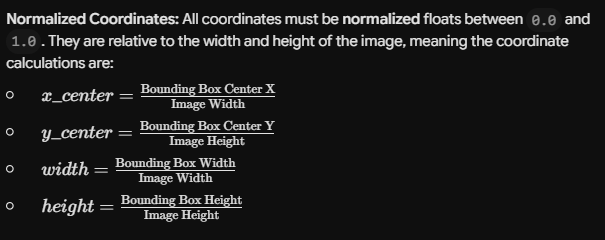

In [7]:
# LetterBoxing - converts bounding box to cooridinates on a unit square

def scale_box(box, width, height):
    scale = 1.0 / max(width, height)
    x, y , w, h = [v * scale for v in box]
    x += (height - width) * scale / 2 if height > width else 0
    y += (width - height) * scale / 2 if width > height else 0
    return [x,y,w,h]

### 2.3 Sneak-peak at the json file for annotations and Aggregation


In [8]:
train_instances_json = "/kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/annotations/instances_train2017.json"

In [9]:
with open(train_instances_json, "r") as file:
    data = json.load(file)

type(data)

dict

In [10]:
data.keys()

dict_keys(['info', 'licenses', 'images', 'annotations', 'categories'])

In [11]:
data['images'][0]

{'license': 3,
 'file_name': '000000391895.jpg',
 'coco_url': 'http://images.cocodataset.org/train2017/000000391895.jpg',
 'height': 360,
 'width': 640,
 'date_captured': '2013-11-14 11:18:45',
 'flickr_url': 'http://farm9.staticflickr.com/8186/8119368305_4e622c8349_z.jpg',
 'id': 391895}

In [12]:
data['annotations'][0]

{'segmentation': [[239.97,
   260.24,
   222.04,
   270.49,
   199.84,
   253.41,
   213.5,
   227.79,
   259.62,
   200.46,
   274.13,
   202.17,
   277.55,
   210.71,
   249.37,
   253.41,
   237.41,
   264.51,
   242.54,
   261.95,
   228.87,
   271.34]],
 'area': 2765.1486500000005,
 'iscrowd': 0,
 'image_id': 558840,
 'bbox': [199.84, 200.46, 77.71, 70.88],
 'category_id': 58,
 'id': 156}

In [13]:
len(data['annotations'])

860001

In [14]:
# Aggregating Metadata
images = {image['id']: image for image in data['images']}

metadata = {}
for annotation in data['annotations']:
    id = annotation['image_id']
    if id not in metadata:
        metadata[id] = {
            "boxes" : [], 
            "labels" : []
        }

    image = images[id]
    box = scale_box(annotation['bbox'], image['width'], image['height'])
    metadata[id]['boxes'].append(box)
    metadata[id]['labels'].append(annotation['category_id'])
    metadata[id]["path"] = images_path + "/" + image['file_name']

metadata = list(metadata.values())    

In [15]:
metadata[0]

{'boxes': [[0.31225, 0.4796250000000001, 0.121421875, 0.11075],
  [0.508234375, 0.3295, 0.05260937500000001, 0.165609375],
  [0.263828125, 0.3085625, 0.049093750000000005, 0.13864062500000002],
  [0.003, 0.30376562500000004, 0.05460937500000001, 0.273984375],
  [0.54153125, 0.168078125, 0.456265625, 0.537046875],
  [0.3735625, 0.23315625, 0.0310625, 0.11989062500000001],
  [0.640515625, 0.503, 0.11225000000000002, 0.07831250000000001],
  [0.0015, 0.168, 0.1454375, 0.25039062500000003],
  [0.431859375, 0.187984375, 0.049609375000000004, 0.096203125],
  [0.005203125, 0.57884375, 0.56146875, 0.244359375],
  [0.6461562500000001,
   0.48187500000000005,
   0.11373437500000001,
   0.08809375000000001]],
 'labels': [58, 44, 44, 47, 1, 44, 50, 1, 44, 67, 50],
 'path': '/kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/train2017/000000558840.jpg'}

In [16]:
!pip install pycocotools

In [17]:
len(metadata)

117266